# Exploratory Data Analysis — Fraud Detection Capstone
**Dataset:** Credit Card Transactions Fraud Detection (Sparkov Simulated)  
**Goal:** Understand data distribution, class imbalance, feature patterns, and fraud signals before modelling.

## 1. Setup & Data Loading

In [2]:
import os
os.chdir('..')  # move up from notebooks/ to project root

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

TRAIN_PATH = 'data/raw/fraudTrain.csv'
TEST_PATH  = 'data/raw/fraudTest.csv'

df = pd.read_csv(TRAIN_PATH, index_col=0)
df_test = pd.read_csv(TEST_PATH, index_col=0)

print(f'Train shape : {df.shape}')
print(f'Test shape  : {df_test.shape}')
df.head()

Train shape : (1296675, 22)
Test shape  : (555719, 22)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## 2. Basic Data Quality Check

In [4]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
print(df.isnull().sum())
print(f'\n=== Duplicate Rows ===')
print(df.duplicated().sum())

=== Data Types ===
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

=== Missing Values ===
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
s

In [5]:
print('=== Numerical Summary ===')
df.describe().T

=== Numerical Summary ===


,count,mean,std,min,25%,50%,75%,max
cc_num,1296675.0,4.171920e+17,1.308806e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1296675.0,7.035104e+01,1.603160e+02,1.000000e+00,9.650000e+00,4.752000e+01,8.314000e+01,2.894890e+04
zip,1296675.0,4.880067e+04,2.689322e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.978300e+04
lat,1296675.0,3.853762e+01,5.075808e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1296675.0,-9.022634e+01,1.375908e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1296675.0,8.882444e+04,3.019564e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06
unix_time,1296675.0,1.349244e+09,1.284128e+07,1.325376e+09,1.338751e+09,1.349250e+09,1.359385e+09,1.371817e+09
merch_lat,1296675.0,3.853734e+01,5.109788e+00,1.902779e+01,3.473357e+01,3.936568e+01,4.195716e+01,6.751027e+01
merch_long,1296675.0,-9.022646e+01,1.377109e+01,-1.666712e+02,-9.689728e+01,-8.743839e+01,-8.023680e+01,-6.695090e+01
is_fraud,1296675.0,5.788652e-03,7.586269e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


## 3. Class Imbalance Analysis

Legitimate transactions : 1,289,169
Fraudulent transactions : 7,506
Fraud rate              : 0.5789%


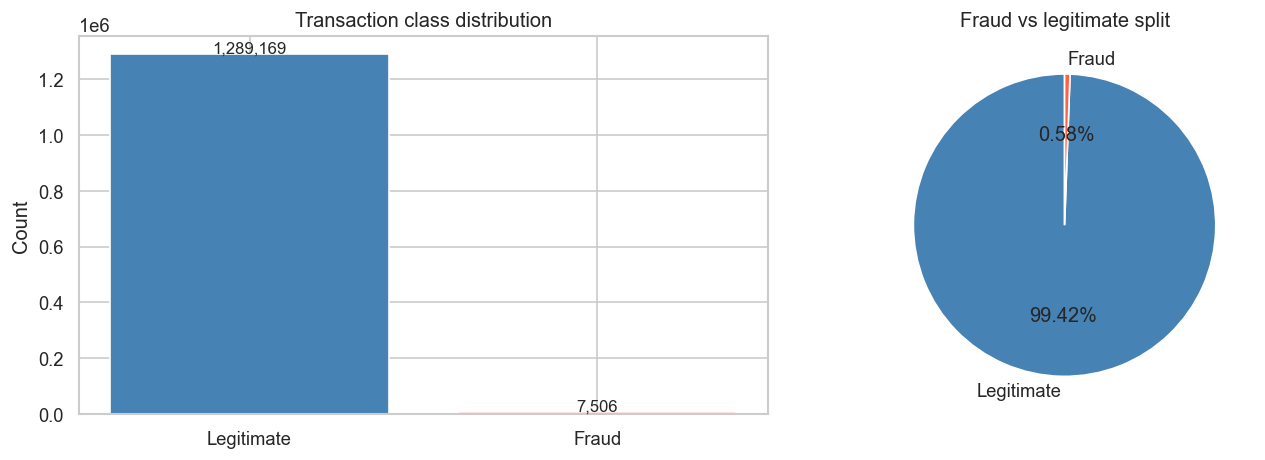

Observation: Severe class imbalance — only 0.58% fraud. SMOTE will be essential during training.


In [6]:
fraud_counts = df['is_fraud'].value_counts()
fraud_rate   = df['is_fraud'].mean()

print(f'Legitimate transactions : {fraud_counts[0]:,}')
print(f'Fraudulent transactions : {fraud_counts[1]:,}')
print(f'Fraud rate              : {fraud_rate:.4%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Transaction class distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%', colors=['steelblue', 'tomato'],
            startangle=90)
axes[1].set_title('Fraud vs legitimate split')

plt.tight_layout()
plt.savefig('reports/figures/class_distribution.png', bbox_inches='tight')
plt.show()
print('Observation: Severe class imbalance — only 0.58% fraud. SMOTE will be essential during training.')

## 4. Transaction Amount Analysis

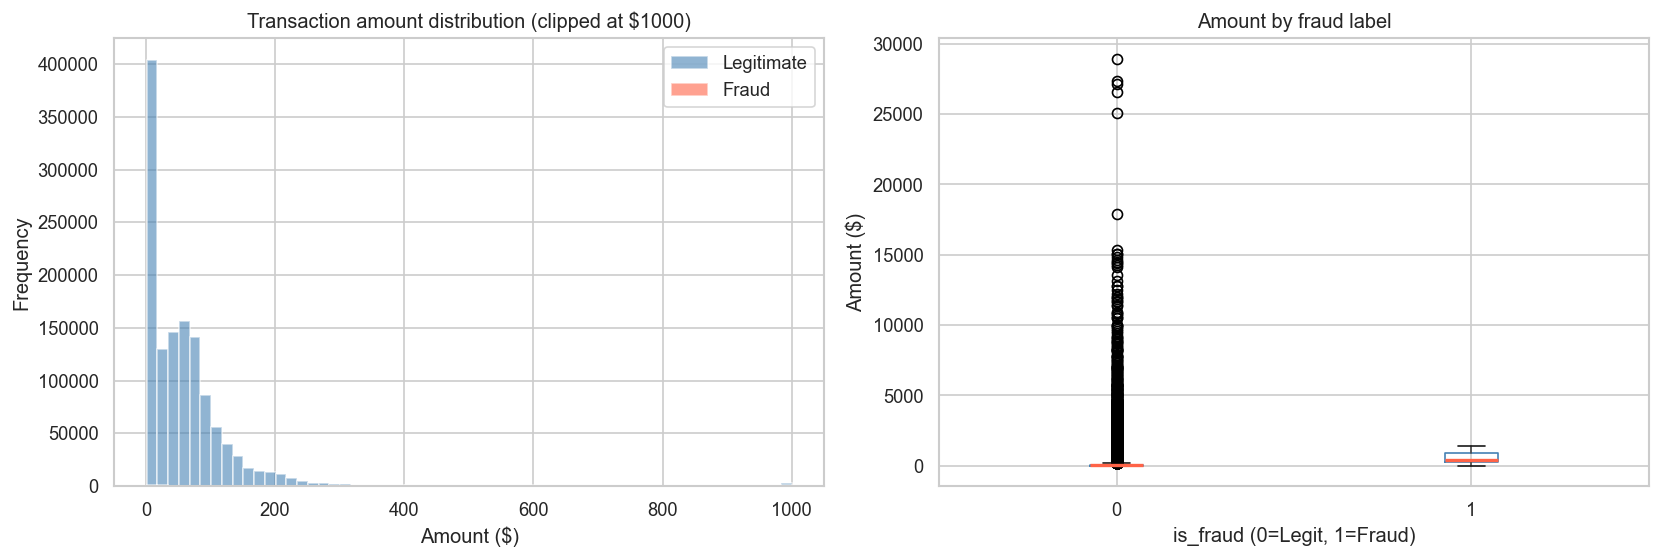

Legitimate median amt: $ 47.28
Fraud median amt     : $ 396.5
Observation: Fraudulent transactions tend to have higher amounts.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by class
df[df['is_fraud']==0]['amt'].clip(upper=1000).plot(
    kind='hist', bins=60, alpha=0.6, color='steelblue',
    label='Legitimate', ax=axes[0])
df[df['is_fraud']==1]['amt'].clip(upper=1000).plot(
    kind='hist', bins=60, alpha=0.6, color='tomato',
    label='Fraud', ax=axes[0])
axes[0].set_title('Transaction amount distribution (clipped at $1000)')
axes[0].set_xlabel('Amount ($)')
axes[0].legend()

# Boxplot
df.boxplot(column='amt', by='is_fraud', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2))
axes[1].set_title('Amount by fraud label')
axes[1].set_xlabel('is_fraud (0=Legit, 1=Fraud)')
axes[1].set_ylabel('Amount ($)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('reports/figures/amount_distribution.png', bbox_inches='tight')
plt.show()

print('Legitimate median amt: $', round(df[df['is_fraud']==0]['amt'].median(), 2))
print('Fraud median amt     : $', round(df[df['is_fraud']==1]['amt'].median(), 2))
print('Observation: Fraudulent transactions tend to have higher amounts.')

## 5. Temporal Patterns

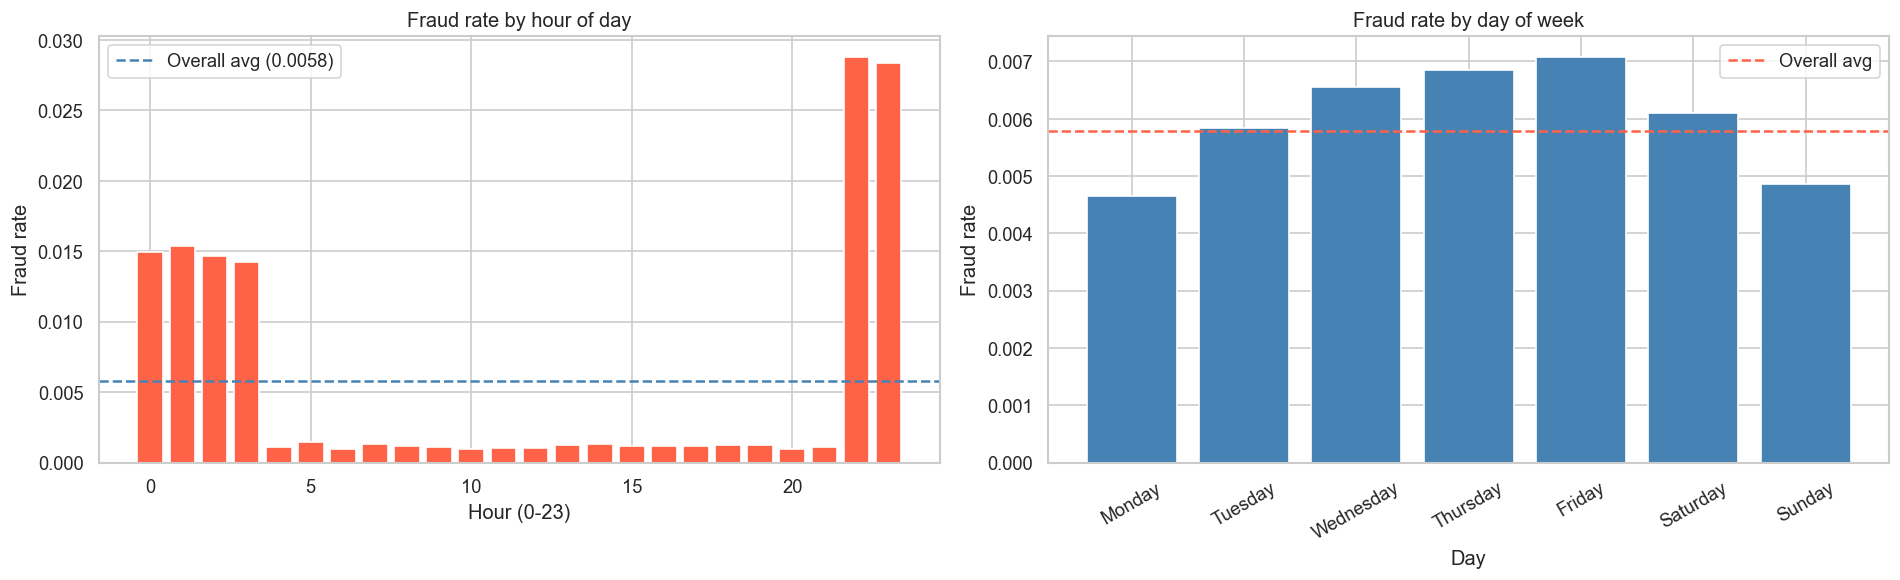

Observation: Fraud spikes significantly during late night hours (0-3am).


In [8]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour']        = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.day_name()
df['month']       = df['trans_date_trans_time'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fraud rate by hour
hourly = df.groupby('hour')['is_fraud'].mean().reset_index()
axes[0].bar(hourly['hour'], hourly['is_fraud'], color='tomato', edgecolor='white')
axes[0].set_title('Fraud rate by hour of day')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Fraud rate')
axes[0].axhline(fraud_rate, color='steelblue', linestyle='--', label=f'Overall avg ({fraud_rate:.4f})')
axes[0].legend()

# Fraud rate by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('day_of_week')['is_fraud'].mean().reindex(dow_order)
axes[1].bar(daily.index, daily.values, color='steelblue', edgecolor='white')
axes[1].set_title('Fraud rate by day of week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fraud rate')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(fraud_rate, color='tomato', linestyle='--', label=f'Overall avg')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/figures/temporal_patterns.png', bbox_inches='tight')
plt.show()
print('Observation: Fraud spikes significantly during late night hours (0-3am).')

## 6. Merchant Category Analysis

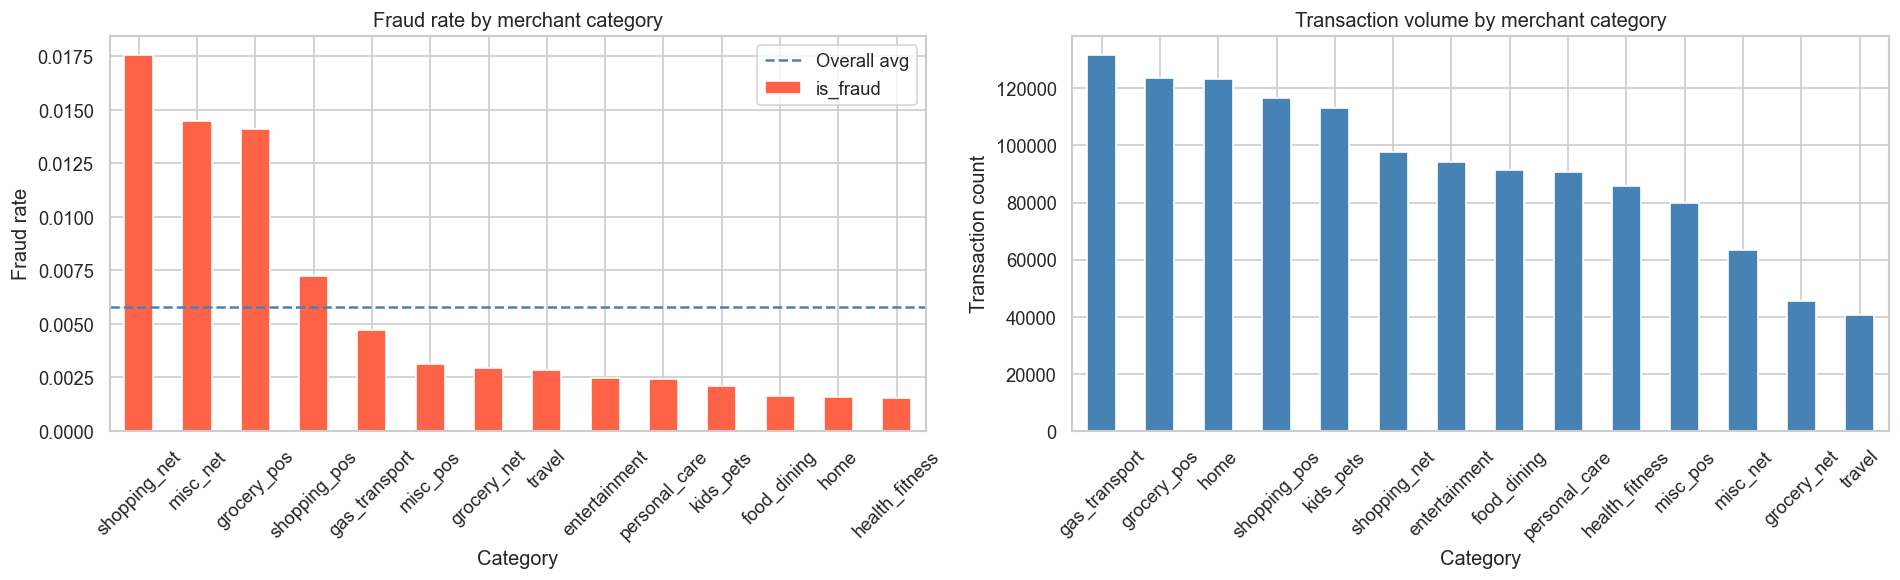

Top 3 highest fraud rate categories:
category
shopping_net    0.017561
misc_net        0.014458
grocery_pos     0.014098


In [9]:
cat_fraud = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
cat_count = df.groupby('category')['is_fraud'].count()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cat_fraud.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Fraud rate by merchant category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Fraud rate')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(fraud_rate, color='steelblue', linestyle='--', label='Overall avg')
axes[0].legend()

cat_count.sort_values(ascending=False).plot(kind='bar', ax=axes[1],
                                             color='steelblue', edgecolor='white')
axes[1].set_title('Transaction volume by merchant category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Transaction count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('reports/figures/category_analysis.png', bbox_inches='tight')
plt.show()

print('Top 3 highest fraud rate categories:')
print(cat_fraud.head(3).to_string())

## 7. Demographic Analysis

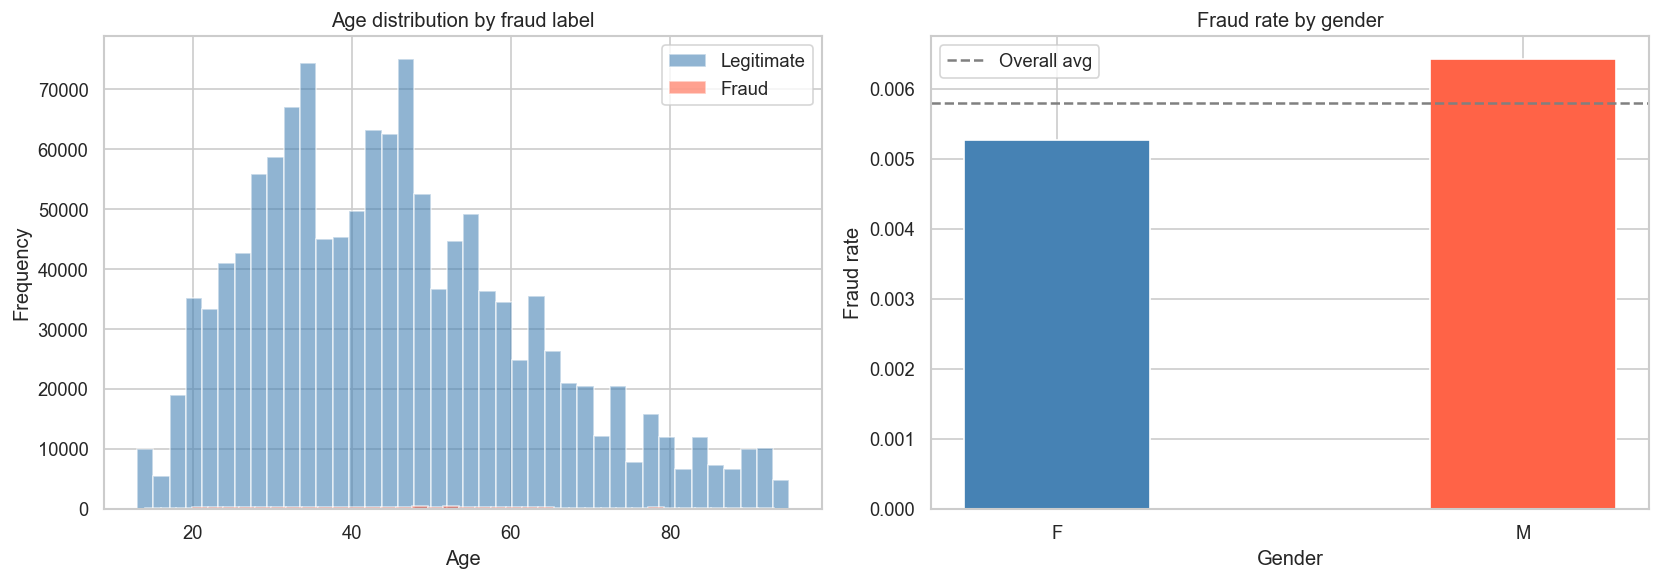

Fraud rate by gender:
gender
F    0.005262
M    0.006426

Age stats (fraud)    : mean=48.3, median=47
Age stats (legit)    : mean=45.5, median=43


In [10]:
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by fraud
df[df['is_fraud']==0]['age'].plot(kind='hist', bins=40, alpha=0.6,
                                   color='steelblue', label='Legitimate', ax=axes[0])
df[df['is_fraud']==1]['age'].plot(kind='hist', bins=40, alpha=0.6,
                                   color='tomato', label='Fraud', ax=axes[0])
axes[0].set_title('Age distribution by fraud label')
axes[0].set_xlabel('Age')
axes[0].legend()

# Fraud rate by gender
gender_fraud = df.groupby('gender')['is_fraud'].mean()
axes[1].bar(gender_fraud.index, gender_fraud.values,
            color=['steelblue', 'tomato'], edgecolor='white', width=0.4)
axes[1].set_title('Fraud rate by gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Fraud rate')
axes[1].axhline(fraud_rate, color='gray', linestyle='--', label='Overall avg')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/figures/demographic_analysis.png', bbox_inches='tight')
plt.show()

print('Fraud rate by gender:')
print(gender_fraud.to_string())
print(f'\nAge stats (fraud)    : mean={df[df.is_fraud==1]["age"].mean():.1f}, median={df[df.is_fraud==1]["age"].median():.0f}')
print(f'Age stats (legit)    : mean={df[df.is_fraud==0]["age"].mean():.1f}, median={df[df.is_fraud==0]["age"].median():.0f}')

## 8. Geographic Analysis

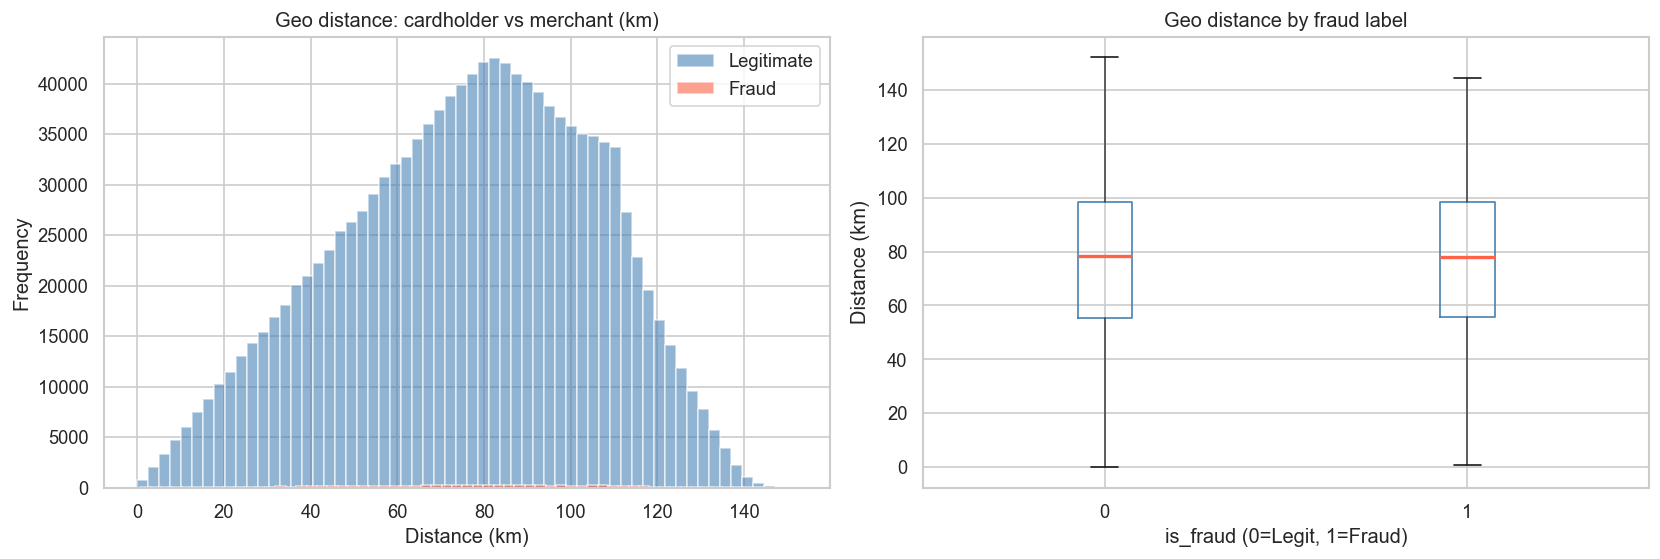

Median geo distance (legit) : 78.23 km
Median geo distance (fraud) : 77.93 km
Observation: Fraudulent transactions occur at greater distances from cardholder home.


In [11]:
from math import radians

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['geo_distance'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['is_fraud']==0]['geo_distance'].clip(upper=200).plot(
    kind='hist', bins=60, alpha=0.6, color='steelblue', label='Legitimate', ax=axes[0])
df[df['is_fraud']==1]['geo_distance'].clip(upper=200).plot(
    kind='hist', bins=60, alpha=0.6, color='tomato', label='Fraud', ax=axes[0])
axes[0].set_title('Geo distance: cardholder vs merchant (km)')
axes[0].set_xlabel('Distance (km)')
axes[0].legend()

df.boxplot(column='geo_distance', by='is_fraud', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2))
axes[1].set_title('Geo distance by fraud label')
axes[1].set_xlabel('is_fraud (0=Legit, 1=Fraud)')
axes[1].set_ylabel('Distance (km)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('reports/figures/geo_analysis.png', bbox_inches='tight')
plt.show()

print(f'Median geo distance (legit) : {df[df.is_fraud==0]["geo_distance"].median():.2f} km')
print(f'Median geo distance (fraud) : {df[df.is_fraud==1]["geo_distance"].median():.2f} km')
print('Observation: Fraudulent transactions occur at greater distances from cardholder home.')

## 9. Correlation Analysis

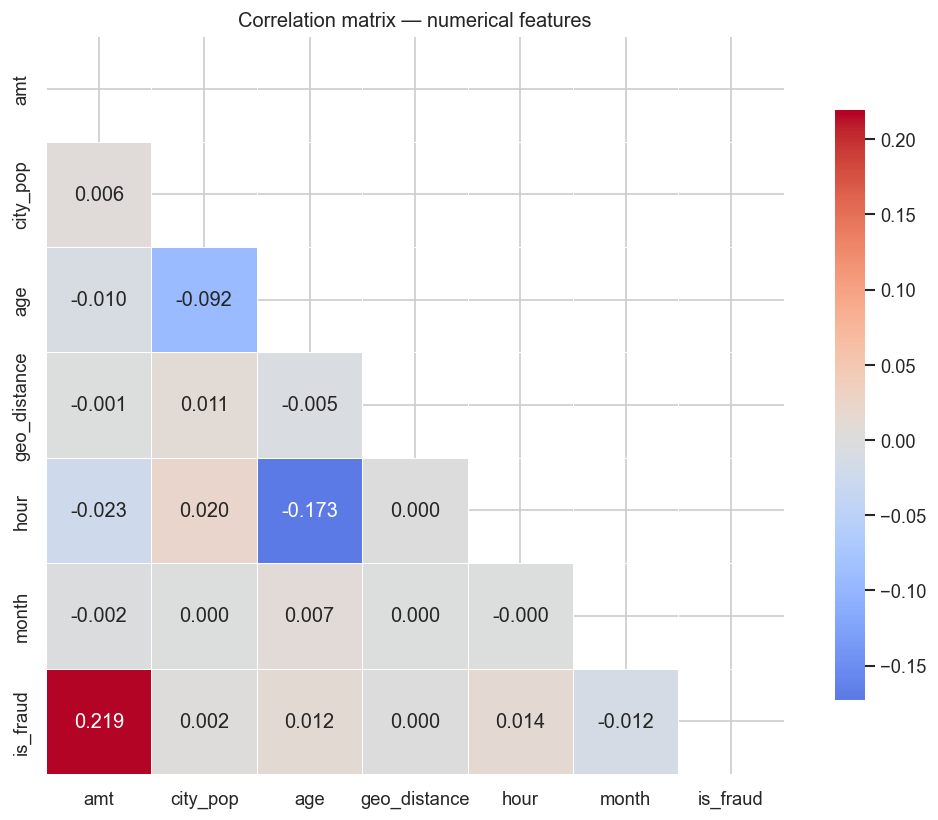

Correlation with is_fraud:
amt             0.219404
hour            0.013799
age             0.012244
city_pop        0.002136
geo_distance    0.000403
month          -0.012409


In [12]:
num_cols = ['amt', 'city_pop', 'age', 'geo_distance', 'hour', 'month', 'is_fraud']
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation matrix — numerical features')
plt.tight_layout()
plt.savefig('reports/figures/correlation_matrix.png', bbox_inches='tight')
plt.show()

print('Correlation with is_fraud:')
print(corr['is_fraud'].drop('is_fraud').sort_values(ascending=False).to_string())

## 10. EDA Summary

In [13]:
summary = {
    'Total transactions'      : len(df),
    'Fraudulent transactions' : df['is_fraud'].sum(),
    'Fraud rate'              : f"{df['is_fraud'].mean():.4%}",
    'Avg fraud amount'        : f"${df[df.is_fraud==1]['amt'].mean():.2f}",
    'Avg legit amount'        : f"${df[df.is_fraud==0]['amt'].mean():.2f}",
    'Peak fraud hour'         : f"{df.groupby('hour')['is_fraud'].mean().idxmax()}:00",
    'Highest fraud category'  : df.groupby('category')['is_fraud'].mean().idxmax(),
    'Missing values'          : df.isnull().sum().sum(),
    'Duplicate rows'          : df.duplicated().sum(),
}

print('=' * 45)
print('         EDA SUMMARY — FRAUD DETECTION')
print('=' * 45)
for k, v in summary.items():
    print(f'{k:<30} : {v}')
print('=' * 45)
print()
print('Key takeaways for modelling:')
print('1. Severe class imbalance (0.58%) → SMOTE required')
print('2. Fraud amount is significantly higher than legit')
print('3. Late night hours (0-3am) show elevated fraud rates')
print('4. Geo distance is a strong differentiating feature')
print('5. No missing values — clean dataset, ready for preprocessing')

         EDA SUMMARY — FRAUD DETECTION
Total transactions             : 1296675
Fraudulent transactions        : 7506
Fraud rate                     : 0.5789%
Avg fraud amount               : $531.32
Avg legit amount               : $67.67
Peak fraud hour                : 22:00
Highest fraud category         : shopping_net
Missing values                 : 0
Duplicate rows                 : 0

Key takeaways for modelling:
1. Severe class imbalance (0.58%) → SMOTE required
2. Fraud amount is significantly higher than legit
3. Late night hours (0-3am) show elevated fraud rates
4. Geo distance is a strong differentiating feature
5. No missing values — clean dataset, ready for preprocessing
